In [1]:
import yfinance as yf
import pandas as pds
import numpy as np
import os
from src.utils.download_data import make_features_micro, make_features_macro
tickers = [
    # --- 1. INDICES & MACRO (Les piliers) ---
    "SPY",      # S&P 500 (Benchmark)
    "QQQ",      # Nasdaq 100 (Tech/Growth)
    "DIA",      # Dow Jones (Industrie/Blue Chips)
    "IWM",      # Russell 2000 (Small Caps - indicateur de risque)
    "TLT",      # 20+ Year Treasury Bond (Taux Longs)
    "IEF",      # 7-10 Year Treasury Bond (Taux Moyens)
    "SHY",      # 1-3 Year Treasury Bond (Cash Proxy/Taux Courts)
    "GLD",      # Gold (Or - valeur refuge/inflation)
    "SLV",      # Silver (Industrie + Refuge)
    "USO",      # Oil Fund (Pétrole)
    "UUP",      # US Dollar Index (Devise)

    # --- 2. ETFS SECTORIELS (Tes cibles probables pour le RL) ---
    "XLK",      # Technology
    "XLF",      # Financials
    "XLE",      # Energy
    "XLV",      # Health Care
    "XLI",      # Industrials
    "XLP",      # Consumer Staples (Défensif)
    "XLY",      # Consumer Discretionary (Cyclique)
    "XLB",      # Materials
    "XLU",      # Utilities
    "XLRE",     # Real Estate (Attention: Historique plus court, souvent inclus dans XLF avant)

    # --- 3. TECH & COM (L'innovation) ---
    # Mix de "Vieux" (1995 compatible) et "Nouveau"
    "AAPL", "MSFT", "IBM", "INTC", "CSCO", "ADBE", "ORCL", "TXN",  # Les historiques (1995+)
    "NVDA", "AMD", "QCOM", "AMAT", "MU", "ADI",                    # Semi-conducteurs
    "GOOGL", "AMZN", "META", "NFLX", "CRM",                        # Les géants du Web (viendront plus tard dans la timeline)
    "T", "VZ", "CMCSA", "DIS",                                     # Télécoms & Média

    # --- 4. FINANCE (Le cycle de crédit) ---
    "JPM", "BAC", "WFC", "C",            # Big Banks
    "AXP", "GS", "MS", "SCHW",           # Investment & Payments
    "BRK-B", "TRV", "ALL", "AIG",        # Assurances & Conglomérats
    "SPG", "O", "PLD", "AMT",            # Immobilier (REITs majeurs)

    # --- 5. ÉNERGIE (L'inflation) ---
    "XOM", "CVX", "COP", "SLB", "HAL",   # Pétrole & Services (Historique long)
    "EOG", "VLO", "MPC", "OXY",          # Exploration & Raffinage
    
    # --- 6. SANTÉ (La défense) ---
    "JNJ", "PFE", "MRK", "LLY", "BMY",   # Big Pharma (Historique long)
    "UNH", "CVS", "CI",                  # Assurance Santé
    "AMGN", "GILD", "BIIB",              # Biotech
    "ABT", "MDT", "SYK",                 # Équipements médicaux

    # --- 7. CONSOMMATION (Le consommateur US) ---
    # Staples (Base)
    "WMT", "PG", "KO", "PEP", "COST", "PM", "MO", "CL",
    # Discretionary (Luxe/Cyclique)
    "MCD", "NKE", "HD", "LOW", "SBUX", "TGT", "TJX", "F", "GM",
    
    # --- 8. INDUSTRIE (Le CAPEX) ---
    "GE", "BA", "CAT", "HON", "MMM", "UNP", "UPS", "RTX", "LMT", "DE", "ITW", "EMR",

    # --- 9. MATÉRIAUX (Le cycle physique) ---
    "LIN", "SHW", "DD", "FCX", "NEM", "APD", "ECL"
]

p1,df1 = make_features_micro(tickers,start="1995-01-01",end="2024-06-01")
df1


/home/romain/tensorflow_project/bourse/src/utils/download_data.py:51: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start=start, end=end)
[*********************100%***********************]  119 of 119 completed


,SPY_ret,SPY_vol20,SPY_hl,SPY_mom21,SPY_ma20r,SPY_ma50r,SPY_rsi14,SPY_atr14,QQQ_ret,QQQ_vol20,...,APD_rsi14,APD_atr14,ECL_ret,ECL_vol20,ECL_hl,ECL_mom21,ECL_ma20r,ECL_ma50r,ECL_rsi14,ECL_atr14
Date,,,,,,,,,,,,,,,,,,,,,
1995-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1995-01-04,0.004767,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,-0.012196,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1995-01-05,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,0.018239,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1995-01-06,0.001018,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1995-01-09,0.001018,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,0.011976,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-05-24,0.006595,-0.525047,-0.582851,1.160026,0.599523,0.268154,0.956708,-1.505917,0.009412,-1.244844,...,0.814382,-1.744494,0.005049,-0.574046,-1.127148,0.650111,0.103284,-0.233226,0.485799,-2.273137
2024-05-28,0.000698,-0.515767,-0.567568,0.887298,0.539446,0.288633,0.928848,-1.388041,0.003771,-1.208860,...,0.769253,-1.708300,-0.023360,-0.059879,2.557515,0.077245,-0.988077,-0.881553,-1.295768,-1.935583
2024-05-29,-0.007027,-1.575210,-1.172520,0.541964,0.019941,-0.034137,0.377763,-1.222091,-0.007073,-1.999493,...,0.528333,-1.037946,-0.012175,-0.160761,-0.711499,-0.204334,-1.498682,-1.196046,-1.606749,-1.801063


In [2]:
import pandas as pd
na_per_col = df1.isna().sum()

tickers = na_per_col.groupby(lambda c: c.split("_")[0])

result = pd.DataFrame({
    "max_na": tickers.max(),
    "feature_max_na": tickers.idxmax(),
    "total_na": tickers.sum()
}).sort_values("max_na", ascending=False)

print(result)

result = result[result["max_na"] > 200]
print(result)




      max_na feature_max_na  total_na
XLRE    5337     XLRE_ma50r     37152
META    4485     META_ma50r     31188
MPC     4258      MPC_ma50r     29599
GM      4108       GM_ma50r     28549
PM      3432       PM_ma50r     23817
...      ...            ...       ...
WFC      108      WFC_ma50r       549
WMT      108      WMT_ma50r       549
VLO      108      VLO_ma50r       549
VZ       108       VZ_ma50r       549
XOM      108      XOM_ma50r       549

[119 rows x 3 columns]
       max_na feature_max_na  total_na
XLRE     5337     XLRE_ma50r     37152
META     4485     META_ma50r     31188
MPC      4258      MPC_ma50r     29599
GM       4108       GM_ma50r     28549
PM       3432       PM_ma50r     23817
UUP      3169      UUP_ma50r     21976
SLV      2959      SLV_ma50r     20506
USO      2946      USO_ma50r     20415
GLD      2597      GLD_ma50r     17972
GOOGL    2533    GOOGL_ma50r     17524
CRM      2493      CRM_ma50r     17244
TLT      2015      TLT_ma50r     13898
IEF      2015

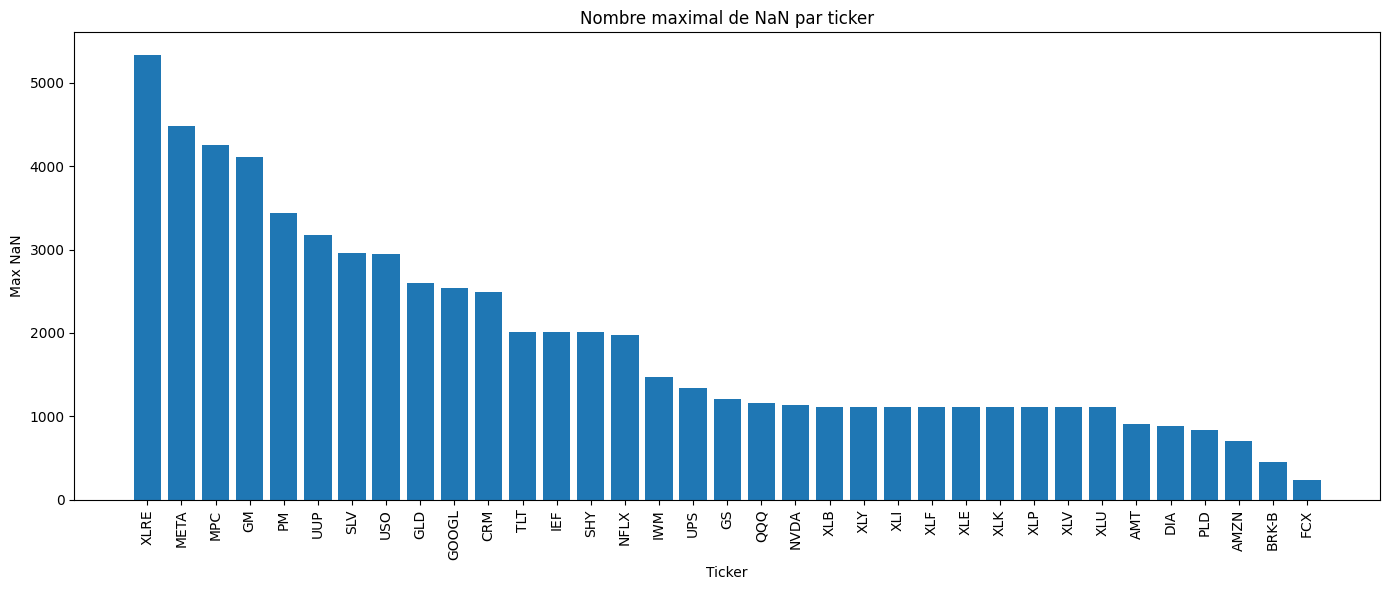

In [3]:
import matplotlib.pyplot as plt

# on suppose que ton tableau s'appelle "result"
# et qu'il contient : max_na, feature_max_na, total_na

plt.figure(figsize=(14, 6))
plt.bar(result.index, result["max_na"])
plt.xticks(rotation=90)
plt.xlabel("Ticker")
plt.ylabel("Max NaN")
plt.title("Nombre maximal de NaN par ticker")
plt.tight_layout()
plt.show()


In [4]:
import numpy as np
import pandas as pd

# Imaginons que tu as identifié tes groupes de colonnes
# NUM_ASSETS = 135 (environ)
# FEATURES_PER_ASSET = 7 (ex: Close, Returns, Volatility, RSI, MACD, etc.)
# MACRO_FEATURES = 7 (ex: Taux, VIX, etc.)

def reshape_data_for_transformer(df, window_size=60):
    """
    Transforme le DataFrame plat (T, F) en fenêtres glissantes structurées.
    """
    data_values = df.values # (7405, 952)
    
    X = []
    
    # On parcourt le temps
    for i in range(window_size, len(data_values)):
        # 1. Extraire la fenêtre temporelle (ex: les 60 derniers jours)
        window = data_values[i-window_size : i] # Shape (60, 952)
        
        # 2. C'est ici que la magie opère : Séparer les actifs
        # Supposons que les 945 premières colonnes sont les actifs (135 * 7)
        # et les 7 dernières sont la Macro
        
        assets_data = window[:, :952] # (60, 945)
        
        # Reshape des actifs pour isoler chaque ticker
        # Shape devient (60, 135, 7) -> (Temps, Actifs, Features)
        assets_reshaped = assets_data.reshape(window_size, 119, 8)
        
        # Pour la Macro, on peut la répéter pour chaque actif ou la traiter à part
        # Ici, on la garde à part pour l'architecture "Dual-Input"
        
        X.append((assets_reshaped))
        
    return X
# Remplacement des NaN dans votre DataFrame 'df1' (ou le DataFrame final après feature engineering)
# Attention : Assurez-vous que les colonnes 'Prix' sont bien normalisées AVANT de mettre 0
df1 = df1.fillna(0) 

# Vous pouvez également vérifier les infinis, car ils causent aussi des problèmes
df1.replace([np.inf, -np.inf], 0, inplace=True)

X = reshape_data_for_transformer(df1, window_size=60)
print(f"Nombre de fenêtres créées: {len(X)}")
print(f"Shape d'une fenêtre (Actifs, Macro): {X[0][0].shape}")

Nombre de fenêtres créées: 7345
Shape d'une fenêtre (Actifs, Macro): (119, 8)


In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader

class FinancialDataset(Dataset):
    def __init__(self, X_data):
        # X_data est ta liste de numpy arrays (60, 119, 8)
        self.data = X_data

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        # On convertit en FloatTensor PyTorch
        # Shape: (60, 119, 8) -> (Time, Assets, Features)
        return torch.FloatTensor(self.data[idx])

# Création du DataLoader
dataset = FinancialDataset(X)
# Batch size 32 ou 64 selon ta VRAM
dataloader = DataLoader(dataset, batch_size=16, shuffle=False) 

# Vérification d'un batch
sample_batch = next(iter(dataloader))
print(f"Shape du Batch PyTorch: {sample_batch.shape}") 
# Doit afficher: torch.Size([32, 60, 119, 8]) -> (Batch, Time, Assets, Features)

Shape du Batch PyTorch: torch.Size([2, 60, 119, 8])


In [6]:
import torch.nn as nn
import math

class PortfolioTransformer(nn.Module):
    def __init__(self, num_assets=119, num_features=8, d_model=64, nhead=4, num_layers=2, dropout=0.1):
        super(PortfolioTransformer, self).__init__()
        
        self.num_assets = num_assets
        self.d_model = d_model
        
        # 1. Projection des Features (8 -> 64)
        self.feature_embedding = nn.Linear(num_features, d_model)
        
        # 2. Encodage Positionnel (Pour que le modèle sache que J-1 != J-60)
        self.pos_encoder = PositionalEncoding(d_model, dropout)
        
        # 3. Temporal Transformer Encoder (Traite l'histoire)
        # batch_first=True est important ici
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, batch_first=True, dropout=dropout)
        self.temporal_transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        
        # 4. Cross-Asset Attention (Corrélations entre actifs)
        # On utilise une couche d'attention pour mixer les infos des 119 actifs
        self.cross_asset_attention = nn.MultiheadAttention(embed_dim=d_model, num_heads=nhead, batch_first=True)
        
        # 5. Tête de Décision (Allocation)
        # On projette chaque actif vers un score scalaire
        self.decision_head = nn.Linear(d_model, 1)
        
        # Token "Cash" apprenable (Actif N+1)
        self.cash_embedding = nn.Parameter(torch.randn(1, d_model))

    def forward(self, x):
        # x shape: (Batch, Time, Assets, Features) -> ex: (32, 60, 119, 8)
        batch_size, seq_len, n_assets, n_feats = x.shape
        
        # --- ÉTAPE A : Traitement Temporel (Indépendant par actif) ---
        
        # On fusionne Batch et Assets pour traiter chaque série temporelle en parallèle
        # New shape: (Batch * Assets, Time, Features)
        x_flat = x.view(batch_size * n_assets, seq_len, n_feats)
        
        # Embedding + Positional Encoding
        x_emb = self.feature_embedding(x_flat) # (B*N, T, d_model)
        x_emb = self.pos_encoder(x_emb)
        
        # Passage dans le Transformer Temporel
        # Le modèle apprend les patterns chartistes ici
        x_temp = self.temporal_transformer(x_emb) # (B*N, T, d_model)
        
        # On garde seulement le dernier état (le plus récent, à t=0 ou t=60)
        # C'est le "résumé" de l'histoire de l'actif
        last_state = x_temp[:, -1, :] # (B*N, d_model)
        
        # On restaure la dimension des actifs
        # Shape: (Batch, Assets, d_model) -> (32, 119, 64)
        assets_state = last_state.view(batch_size, n_assets, self.d_model)
        
        
        # --- ÉTAPE B : Traitement Spatial (Cross-Asset) ---
        
        # Self-Attention sur l'axe des actifs
        # Query=Key=Value = assets_state
        # Le modèle compare Apple avec Microsoft, Exxon, etc.
        spatial_out, _ = self.cross_asset_attention(assets_state, assets_state, assets_state)
        
        # Connexion résiduelle (souvent utile) + Norm (optionnel, simplifié ici)
        assets_final = spatial_out + assets_state
        
        
        # --- ÉTAPE C : Allocation (Softmax) ---
        
        # Calcul des scores pour les 119 actifs
        asset_scores = self.decision_head(assets_final) # (Batch, 119, 1)
        asset_scores = asset_scores.squeeze(-1)         # (Batch, 119)
        
        # Gestion du Cash (Actif virtuel)
        # On étend le cash pour le batch size
        cash_score = torch.matmul(self.cash_embedding, self.decision_head.weight.t()) # Score du cash
        cash_score = cash_score.expand(batch_size, 1) # (Batch, 1)
        
        # Concaténation : [Scores Actifs, Score Cash] -> 120 scores
        all_scores = torch.cat([asset_scores, cash_score], dim=1) # (Batch, 120)
        
        # Softmax pour avoir des poids qui somment à 1 (Long Only)
        weights = torch.softmax(all_scores, dim=1)
        
        return weights

# Helper Class pour l'encodage positionnel (Standard)
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, dropout=0.1, max_len=5000):
        super(PositionalEncoding, self).__init__()
        self.dropout = nn.Dropout(p=dropout)
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)
        self.register_buffer('pe', pe)

    def forward(self, x):
        # x: (Batch, Time, Emb)
        x = x + self.pe[:, :x.size(1), :]
        return self.dropout(x)


class PreTrainingWrapper(nn.Module):
    def __init__(self, base_transformer, num_features=8):
        super(PreTrainingWrapper, self).__init__()
        self.transformer = base_transformer
        
        # On remplace la "Decision Head" par une "Reconstruction Head"
        # Entrée : d_model (64 ou 128)
        # Sortie : num_features (8) -> On veut retrouver les features originales
        self.reconstruction_head = nn.Linear(base_transformer.d_model, num_features)

    def forward(self, x):
        # x: (Batch, Time, Assets, Features)
        batch_size, seq_len, n_assets, n_feats = x.shape
        
        # --- ON REPREND LA LOGIQUE DU TRANSFORMER (Partie Encodeur) ---
        # (Je répète le code interne pour clarté, idéalement on modifierait 
        # la méthode forward du modèle de base pour retourner les embeddings)
        
        x_flat = x.view(batch_size * n_assets, seq_len, n_feats)
        x_emb = self.transformer.feature_embedding(x_flat)
        x_emb = self.transformer.pos_encoder(x_emb)
        x_temp = self.transformer.temporal_transformer(x_emb)
        
        # On prend la séquence complète (pour reconstruire toute la fenêtre) 
        # ou juste le dernier point. Pour MAM, reconstruire le dernier point est suffisant.
        last_state = x_temp[:, -1, :] # (B*N, d_model)
        
        assets_state = last_state.view(batch_size, n_assets, self.transformer.d_model)
        
        # Cross-Asset Attention
        spatial_out, _ = self.transformer.cross_asset_attention(assets_state, assets_state, assets_state)
        assets_final = spatial_out + assets_state # (Batch, Assets, d_model)
        
        # --- TÊTE DE RECONSTRUCTION ---
        # Au lieu de Softmax, on projette vers les features (Open, Close, Vol...)
        reconstructed_features = self.reconstruction_head(assets_final) # (Batch, Assets, 8)
        
        return reconstructed_features

In [7]:
# 1. Instancier le modèle
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:


import torch
import torch.nn as nn
import torch.optim as optim
from tqdm.auto import tqdm  # Import magique pour la barre de progression

# 1. Config
MASK_PROB = 0.15  
LEARNING_RATE = 1e-3
EPOCHS = 50 

# 2. Initialisation
# Assure-toi que 'base_model' et 'PreTrainingWrapper' sont définis dans les cellules précédentes
base_model = PortfolioTransformer(num_assets=119, num_features=8, d_model=128).to(device)
pt_model = PreTrainingWrapper(base_model, num_features=8).to(device)

optimizer = optim.Adam(pt_model.parameters(), lr=LEARNING_RATE)
criterion = nn.MSELoss()

# 3. Boucle
print(f"🚀 Début du Pré-entraînement MAM sur {device}...")

for epoch in range(EPOCHS):
    total_loss = 0
    
    # On enveloppe le dataloader avec tqdm
    # desc : Le texte à gauche de la barre
    # leave=True : Garde la barre affichée une fois l'époque finie
    progress_bar = tqdm(dataloader, desc=f"Epoch {epoch+1}/{EPOCHS}", leave=True)
    
    for batch_idx, x_batch in enumerate(progress_bar):
        x_batch = x_batch.to(device) # (Batch, 60, 119, 8)
        
        # --- CRÉATION DU MASQUE (CORRIGÉE) ---
        batch_size, seq_len, n_assets, n_features = x_batch.shape
        
        # 1. Masque binaire de base (Batch, Assets)
        mask_matrix = torch.rand(batch_size, n_assets).to(device) < MASK_PROB
        
        # 2. Création de l'entrée corrompue
        x_masked = x_batch.clone()
        
        # 3. Expansion correcte des dimensions pour le broadcasting
        # On passe de (Batch, Assets) -> (Batch, 1, Assets, 1)
        # Cela permet d'aligner avec (Batch, Time, Assets, Features)
        mask_expanded = mask_matrix.unsqueeze(1).unsqueeze(-1)
        mask_expanded = mask_expanded.expand_as(x_masked)

        # 4. Application du masque
        x_masked[mask_expanded] = 0
        
        # --- FORWARD ---
        reconstructed = pt_model(x_masked) # Sortie: (Batch, Assets, 8)
        
        # --- CALCUL DE LA LOSS ---
        target = x_batch[:, -1, :, :] # (Batch, Assets, 8)
        
        # Filtrage avec le masque d'origine (qui a la bonne taille pour output et target)
        prediction_on_masked = reconstructed[mask_matrix]
        target_on_masked = target[mask_matrix]
        
        loss = criterion(prediction_on_masked, target_on_masked)
        
        # --- BACKPROP ---
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        # --- UI UPDATE ---
        total_loss += loss.item()
        current_avg_loss = total_loss / (batch_idx + 1)
        
        # Affiche la loss en temps réel à droite de la barre
        progress_bar.set_postfix({'loss': loss.item(), 'avg_loss': current_avg_loss})

print("✅ Pré-entraînement terminé. Le modèle comprend la physique du marché.")


/home/romain/tensorflow_project/bourse/venv310/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


🚀 Début du Pré-entraînement MAM sur cuda...


Epoch 1/50:  19%|█▊        | 687/3673 [00:22<01:38, 30.20it/s, loss=1.08, avg_loss=0.983] 